In [9]:
import dataset, features, modeling, plots
import pandas as pd

# Tworzenie modeli

Przy doborze portfeli inwestycyjnych jednym z kluczowych parametrów jest **liczba spółek wchodzących** w ich skład. Liczba ta może być zmienna — co często występuje w portfelach aktywnie zarządzanych — lub stała, co jest typowe dla portfeli dobieranych automatycznie według określonych reguł.

Za optymalną równowagę pomiędzy dywersyfikacją a koncentracją portfela uznaje się zazwyczaj od 10 do 20 spółek. Zbyt duża liczba walorów może prowadzić do osiągania stóp zwrotu zbliżonych do indeksu rynkowego, a często nawet niższych. Z kolei nadmierna specjalizacja powoduje, że wyniki pojedynczych spółek mają zbyt duży wpływ na wartość całego portfela, zwiększając jego ryzyko.

W dalszej części pracy, przy analizie poszczególnych strategii, przyjęto środkową wartość tego przedziału, czyli portfel składający się z 15 spółek.

Kolejnym analizowanym parametrem jest **częstotliwość doboru** portfela, rozpatrywana w wariantach miesięcznym, kwartalnym oraz rocznym. Każda z tych częstotliwości wiąże się z inną równowagą pomiędzy szybkością reakcji na zmiany rynkowe a kosztami oraz stabilnością portfela. W ramach pracy przeprowadzone zostaną testy dla każdego z rozważanych wariantów.

Loaded merged data with 8 price fields


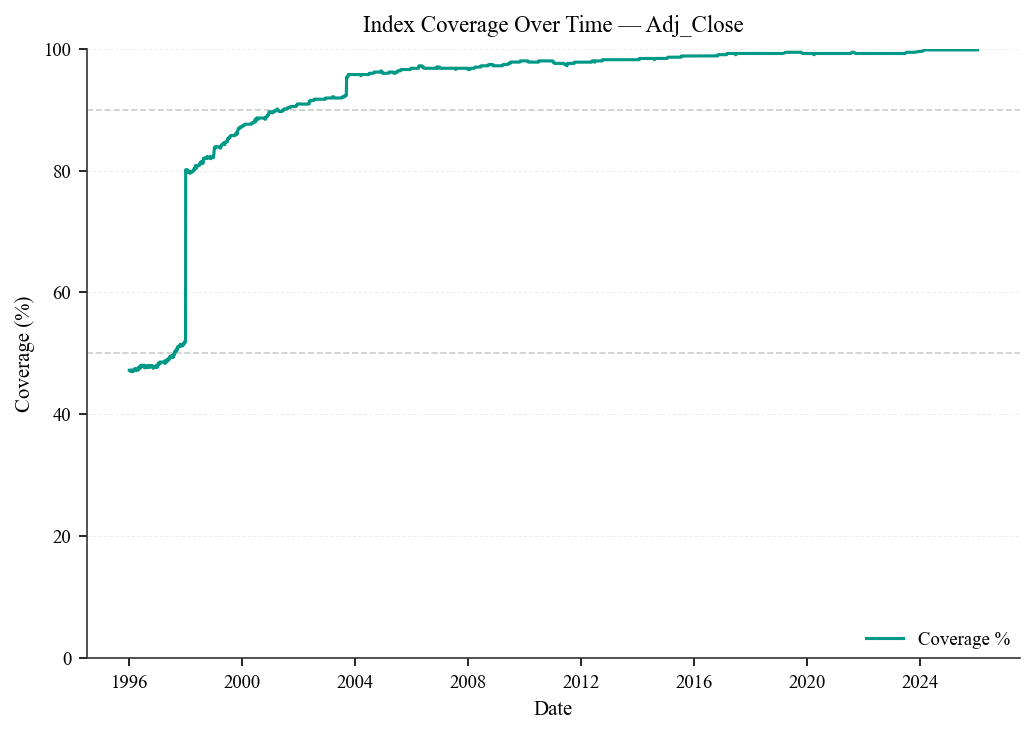

Missing ticker coverage periods:
- AAL:
  missing from 1996-01-02 to 1997-01-13
- AAMRQ:
  missing from 1996-01-02 to 2003-03-10
- ABI:
  missing from 1996-01-02 to 1997-12-29
  missing from 2008-11-18 to 2008-11-20
- ABKFQ:
  missing from 2000-12-11 to 2008-06-10
- ABS:
  missing from 1996-01-02 to 1997-12-29
- ABX:
  missing from 1996-01-02 to 2002-07-18
- ACKH:
  missing from 1996-01-02 to 1997-12-29
- ACV:
  missing from 1996-01-02 to 2006-11-16
- ADCT:
  missing from 1999-08-02 to 2003-09-08
  missing from 2005-05-13 to 2005-06-06
- AET:
  missing from 1996-01-02 to 1997-12-29
- AFS.A:
  missing from 1998-04-08 to 2000-11-29
- AGC:
  missing from 1996-01-02 to 2001-03-22
- AHM:
  missing from 1996-01-02 to 1997-12-29
- AL:
  missing from 1996-01-02 to 2002-07-18
- AM:
  missing from 1996-01-02 to 1997-12-29
- AMH:
  missing from 1996-01-02 to 1997-09-08
- AMP:
  missing from 1996-01-02 to 1999-03-30
- ANDW:
  missing from 1996-01-02 to 1997-12-29
- ANRZQ:
  missing from 2011-06-02

In [10]:
sp500_components: pd.DataFrame = dataset.SP500.load_historical()
merged_data: dict[str, pd.DataFrame] = features.load_merged_data()
coverage: pd.DataFrame = plots.coverage_over_time(
    price_data=merged_data,
    components=sp500_components,
    save_figures=False
)
missing_tickers: pd.DataFrame = pd.read_csv("../data/processed/missing_ticker.csv", index_col=0, parse_dates=True)
benchmark_df: pd.DataFrame = pd.read_csv("../data/processed/benchmark_2026-04-19.csv", index_col=0, parse_dates=True)
N = 15

## Model losowy

Najprostszą strategią, którą można przetestować jest model losowy, który losowo daną liczbę spółek cyklicznie.

In [11]:
modeling.select_random(sp500_components, n=N, coverage=coverage, date="2001-01-01")

{'tickers': ['NWL',
  'BCR',
  'ADI',
  'RF',
  'DG',
  'CSX',
  'CNXT',
  'BMET',
  'RDC',
  'BAX',
  'PD',
  'UNM',
  'MBI',
  'AVY',
  'MTG'],
 'difference': 2}

In [12]:
random_M = modeling.select_random_periodic(
    components=sp500_components,
    n=N,
    start_date="2001-01-01",
    frequency="monthly",
    coverage=coverage
)
plots.summarize_df(random_M)
random_Q = modeling.select_random_periodic(
    components=sp500_components,
    n=N, 
    start_date="2001-01-01",
    frequency="quarterly",
    coverage=coverage
)
plots.summarize_df(random_Q)
random_Y = modeling.select_random_periodic(
    components=sp500_components,
    n=N,
    start_date="2001-01-01",
    frequency="yearly",
    coverage=coverage
)
plots.summarize_df(random_Y)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        301 non-null    datetime64[us]
 1   tickers     301 non-null    object        
 2   difference  301 non-null    int64         
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 7.2+ KB
None


,date,difference
count,301,301.00000000
mean,2013-07-01 13:28:30.299003,0.21926910
min,2001-01-01 00:00:00,0.00000000
25%,2007-04-01 00:00:00,0.00000000
50%,2013-07-01 00:00:00,0.00000000
75%,2019-10-01 00:00:00,0.00000000
max,2026-01-01 00:00:00,2.00000000
std,NaN,0.45287319


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        101 non-null    datetime64[us]
 1   tickers     101 non-null    object        
 2   difference  101 non-null    int64         
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 2.5+ KB
None


,date,difference
count,101,101.00000000
mean,2013-07-01 11:38:36.831683,0.21782178
min,2001-01-01 00:00:00,0.00000000
25%,2007-04-01 00:00:00,0.00000000
50%,2013-07-01 00:00:00,0.00000000
75%,2019-10-01 00:00:00,0.00000000
max,2026-01-01 00:00:00,2.00000000
std,NaN,0.43826842


DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        26 non-null     datetime64[us]
 1   tickers     26 non-null     object        
 2   difference  26 non-null     int64         
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 756.0+ bytes
None


,date,difference
count,26,26.00000000
mean,2013-07-02 06:27:41.538461,0.26923077
min,2001-01-01 00:00:00,0.00000000
25%,2007-04-02 06:00:00,0.00000000
50%,2013-07-02 12:00:00,0.00000000
75%,2019-10-01 18:00:00,0.00000000
max,2026-01-01 00:00:00,2.00000000
std,NaN,0.53349357


,date,tickers,difference
0,2001-01-01,"[NWL, BCR, ADI, RF, DG, CSX, CNXT, BMET, RDC, ...",2
1,2002-01-01,"[HNZ, ADSK, ADP, AWE, CNP, CPNLQ, KMI, MTG, AD...",1
24,2025-01-01,"[CME, KR, HRL, BX, HAL, CINF, DOW, IBM, DAY, T...",0
25,2026-01-01,"[TKO, LIN, AZO, AMCR, NKE, LDOS, T, ADBE, XOM,...",0


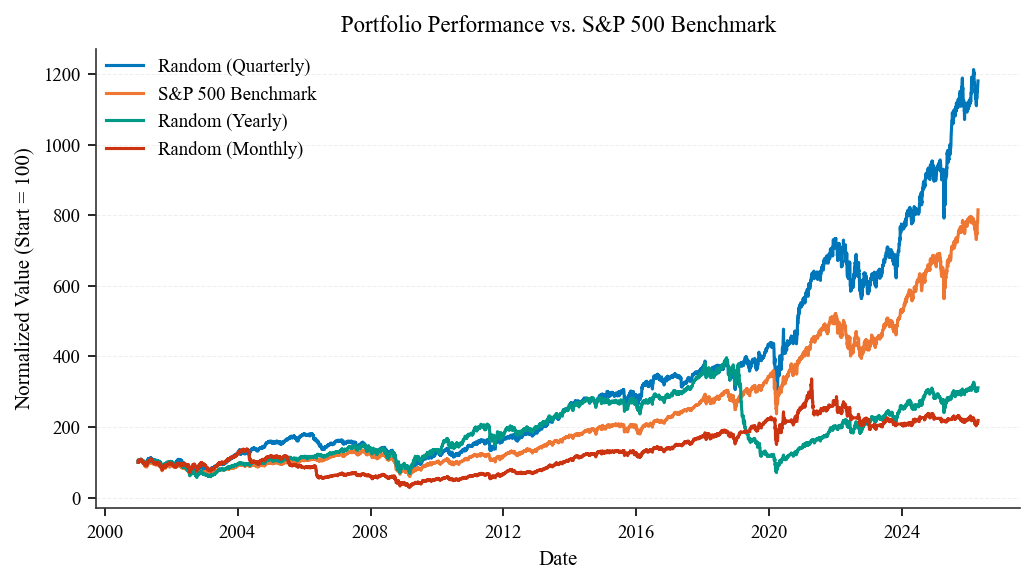

,Random (Quarterly),S&P 500 Benchmark,Random (Yearly),Random (Monthly)
Date,,,,
2001-01-02,100.00000000,100.00000000,100.00000000,100.00000000
2001-01-03,106.38738043,105.02137510,106.38738043,106.38738043
2001-01-04,104.20752139,103.91462970,104.20752139,104.20752139
2001-01-05,100.81902866,101.18692175,100.81902866,100.81902866
2001-01-08,101.52241908,101.01253978,101.52241908,101.52241908
...,...,...,...,...
2026-04-13,1162.40522508,778.63843905,306.93082166,212.57559742
2026-04-14,1170.84993926,793.51742181,306.86247115,214.54477271
2026-04-15,1169.29568738,798.58685969,308.11749130,215.03786897


In [14]:
portfolio_random_M = modeling.backtest_portfolio(
    selected_companies=random_M, 
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_random_Q = modeling.backtest_portfolio(
    selected_companies=random_Q, 
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)
portfolio_random_Y = modeling.backtest_portfolio(
    selected_companies=random_Y, 
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)

plots.YahooFinance.compare_tickers(
    dfs={
        "Random (Monthly)": portfolio_random_M,
        "Random (Quarterly)": portfolio_random_Q,
        "Random (Yearly)": portfolio_random_Y,
        "S&P 500 Benchmark": benchmark_df
    },
    title="Portfolio Performance vs. S&P 500 Benchmark"
)

## Model Monte Carlo

<!-- W każdym rebalansie losuję wiele portfeli (`n_trials`) z aktywnych spółek. Każdy portfel oceniam na podstawie średniej stopy zwrotu i zmienności z okna `lookback_days`, a następnie wybieram najlepszy (score = mean/vol). Dla stabilności odrzucam ekstremalne dzienne zwroty (`max_abs_return`). Wynik backtestuję z uwzględnieniem `coverage` oraz syntetycznego `missing_ticker`. -->

In [15]:
mc_components = modeling.select_monte_carlo_periodic(
    components=sp500_components,
    price_data=merged_data,
    n=N,
    start_date="2001-01-01",
    frequency="quarterly",
    lookback_days=252,
    n_trials=500,
    min_obs=60,
    max_abs_return=2.0,
    coverage=coverage,
 )
plots.summarize_df(mc_components)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        101 non-null    datetime64[us]
 1   tickers     101 non-null    object        
 2   difference  101 non-null    int64         
 3   score       101 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), object(1)
memory usage: 3.3+ KB
None


,date,difference,score
count,101,101.00000000,101.00000000
mean,2013-07-01 11:38:36.831683,0.21782178,0.07324025
min,2001-01-01 00:00:00,0.00000000,-0.00241688
25%,2007-04-01 00:00:00,0.00000000,0.05460288
50%,2013-07-01 00:00:00,0.00000000,0.07922169
75%,2019-10-01 00:00:00,0.00000000,0.09351356
max,2026-01-01 00:00:00,2.00000000,0.12735902
std,NaN,0.43826842,0.03132324


,date,tickers,difference,score
0,2001-01-01,"[WEN, CAH, NBR, COP, ED, SVU, PHM, AZO, STJ, A...",2,0.07556572
1,2001-04-01,"[FDC, MBI, UN, KG, STT, UNM, FMCC, RTN, PBI, B...",1,0.06238200
99,2025-10-01,"[BLK, WELL, PLTR, EOG, VRTX, WRB, ESS, TSLA, A...",0,0.07922169
100,2026-01-01,"[PCAR, CSCO, DG, DD, TAP, WRB, EMR, BEN, WDC, ...",0,0.07543588


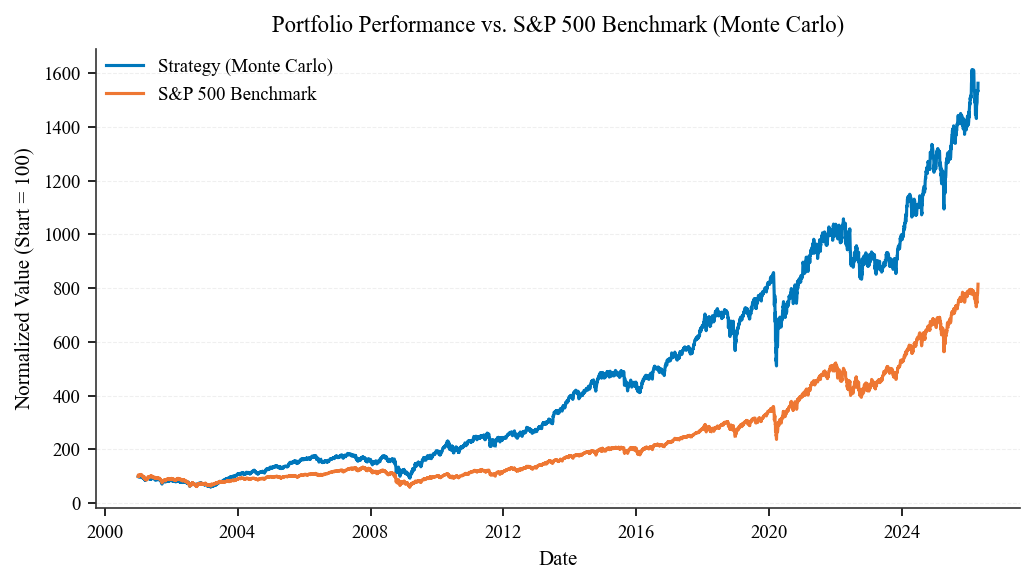

,Strategy (Monte Carlo),S&P 500 Benchmark
Date,,
2001-01-02,100.00000000,100.00000000
2001-01-03,102.08751784,105.02137510
2001-01-04,99.42945510,103.91462970
2001-01-05,97.58734245,101.18692175
2001-01-08,97.66898716,101.01253978
...,...,...
2026-04-13,1533.40845777,778.63843905
2026-04-14,1536.70229486,793.51742181
2026-04-15,1531.47897929,798.58685969


In [16]:
mc_portfolio_value = modeling.backtest_portfolio(
    selected_companies=mc_components,
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
 )

plots.YahooFinance.compare_tickers(
    dfs={
        "Strategy (Monte Carlo)": mc_portfolio_value,
        "S&P 500 Benchmark": benchmark_df
    },
    title="Portfolio Performance vs. S&P 500 Benchmark (Monte Carlo)"
 )